In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

In [46]:
df = pd.read_csv('customer_churn_dataset-training-master.csv')

print('Dataset Shape:')
print(df.shape)

print('\nFirst 5 rows:')
df.head()

Dataset Shape:
(440833, 12)

First 5 rows:


,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0


## Data Explore

In [23]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
CustomerID,440832.0,NaN,NaN,NaN,225398.667955,129531.91855,2.0,113621.75,226125.5,337739.25,449999.0
Age,440832.0,NaN,NaN,NaN,39.373153,12.442369,18.0,29.0,39.0,48.0,65.0
Gender,440832,2,Male,250252,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Tenure,440832.0,NaN,NaN,NaN,31.256336,17.255727,1.0,16.0,32.0,46.0,60.0
Usage Frequency,440832.0,NaN,NaN,NaN,15.807494,8.586242,1.0,9.0,16.0,23.0,30.0
Support Calls,440832.0,NaN,NaN,NaN,3.604437,3.070218,0.0,1.0,3.0,6.0,10.0
Payment Delay,440832.0,NaN,NaN,NaN,12.965722,8.258063,0.0,6.0,12.0,19.0,30.0
Subscription Type,440832,3,Standard,149128,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Contract Length,440832,3,Annual,177198,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Total Spend,440832.0,NaN,NaN,NaN,631.616223,240.803001,100.0,480.0,661.0,830.0,1000.0


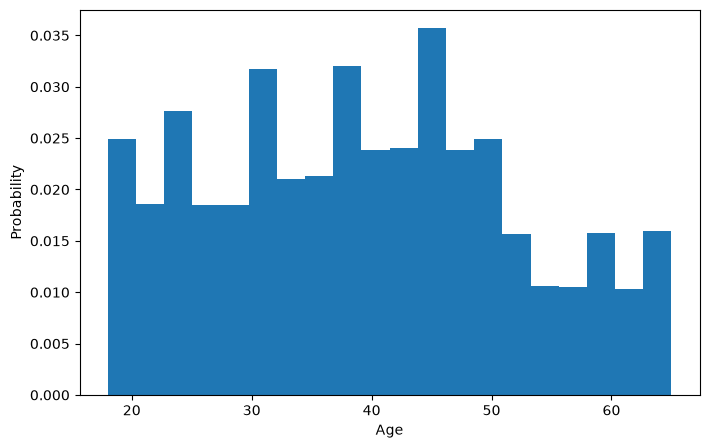

In [24]:
fig , ax = plt.subplots(figsize=(8,5))
ax.hist(
    df['Age'], bins=20, density=True
)
ax.set_xlabel('Age')
ax.set_ylabel('Probability')
plt.show()

#### <b> Age Distribution Observation </b>

The age distribution shows an unusual increase at Age = 65, where the number of observations is significantly higher than other ages. This suggests that 65 may represent a grouped value rather than only people who are exactly 65 years old.

A possible explanation is top-coding, where all ages above a certain threshold (e.g., 65+) are recorded as 65. Therefore, this value should be treated carefully during analysis and modeling, as it may represent a range of ages rather than a single age group.

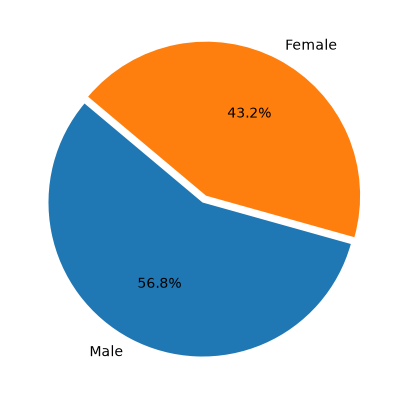

In [25]:
df_gender = df['Gender'].value_counts().reset_index()

fig, ax = plt.subplots(figsize=(8, 5))

ax.pie(df_gender['count'], labels=df_gender['Gender'],autopct='%1.1f%%', startangle=140, explode=[0,0.05])
plt.show()

## Cleaning Data

In [26]:
print('\nMissing values:')
print(df.isnull().sum())

print('\nTarget distribution:')
print(df['Churn'].value_counts(normalize=True))


Missing values:
CustomerID           1
Age                  1
Gender               1
Tenure               1
Usage Frequency      1
Support Calls        1
Payment Delay        1
Subscription Type    1
Contract Length      1
Total Spend          1
Last Interaction     1
Churn                1
dtype: int64

Target distribution:
Churn
1.0    0.567107
0.0    0.432893
Name: proportion, dtype: float64


In [47]:
print(df.__len__())
df = df.dropna()

## Drop CustomerID
df = df.drop(columns=['CustomerID'])
print(df.__len__())



440833
440832


In [48]:

lbe_gender = LabelEncoder()
lbe_gender.fit(df['Gender'].drop_duplicates())
df['Gender'] = lbe_gender.transform(df['Gender'])

lbe_subscriptiontype = LabelEncoder()
lbe_subscriptiontype.fit(df['Subscription Type'].drop_duplicates())
df['Subscription Type'] = lbe_subscriptiontype.transform(df['Subscription Type'])


lbe_Contract = LabelEncoder()
lbe_Contract.fit(df['Contract Length'].drop_duplicates())

df['Contract Length'] = lbe_Contract.transform(df['Contract Length'])

X = df.drop('Churn', axis=1)
y = df['Churn']


In [49]:
X_train_train, X_train_test, y_train_train, y_train_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train_train.shape)

print(X_train_test.shape)

(352665, 10)
(88167, 10)


In [50]:
model = RandomForestClassifier(n_estimators=200)

model.fit(X_train_train, y_train_train)

y_pred = model.predict(X_train_test)
y_prob = model.predict_proba(X_train_test)[:,1]

In [51]:
print(accuracy_score(y_train_test, y_pred))

0.9997618156453094


In [56]:
df_test = pd.read_csv('customer_churn_dataset-testing-master.csv')
df_test_customers = df_test['CustomerID']
df_test.drop(columns=['CustomerID'], inplace=True)
df_test.head()

,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,22,Female,25,14,4,27,Basic,Monthly,598,9,1
1,41,Female,28,28,7,13,Standard,Monthly,584,20,0
2,47,Male,27,10,2,29,Premium,Annual,757,21,0
3,35,Male,9,12,5,17,Premium,Quarterly,232,18,0
4,53,Female,58,24,9,2,Standard,Annual,533,18,0


In [57]:
df_test.isna().sum()

Age                  0
Gender               0
Tenure               0
Usage Frequency      0
Support Calls        0
Payment Delay        0
Subscription Type    0
Contract Length      0
Total Spend          0
Last Interaction     0
Churn                0
dtype: int64

In [58]:
df_test['Gender'] = lbe_gender.transform(df_test['Gender'])
df_test['Subscription Type'] = lbe_subscriptiontype.transform(df_test['Subscription Type'])
df_test['Contract Length'] = lbe_Contract.transform(df_test['Contract Length'])

X_test_test = df_test.drop(columns=['Churn'])
Y_test_test = df_test['Churn']
X_test_test.head()

,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction
0,22,0,25,14,4,27,0,1,598,9
1,41,0,28,28,7,13,2,1,584,20
2,47,1,27,10,2,29,1,0,757,21
3,35,1,9,12,5,17,1,2,232,18
4,53,0,58,24,9,2,2,0,533,18


In [59]:
Y_pred = model.predict(X_test_test)

acc = accuracy_score(Y_test_test, Y_pred)
print(f"Accuracu: {acc}")

Accuracu: 0.5035107341473266


In [60]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(Y_test_test, Y_pred))
print(confusion_matrix(Y_test_test, Y_pred))

              precision    recall  f1-score   support

           0       0.98      0.06      0.11     33881
           1       0.49      1.00      0.66     30493

    accuracy                           0.50     64374
   macro avg       0.73      0.53      0.38     64374
weighted avg       0.75      0.50      0.37     64374

[[ 1960 31921]
 [   40 30453]]


In [61]:
print(y_train_train.value_counts(normalize=True))
print(Y_test_test.value_counts(normalize=True))

Churn
1.0    0.566813
0.0    0.433187
Name: proportion, dtype: float64
Churn
0    0.526315
1    0.473685
Name: proportion, dtype: float64


In [62]:
model = RandomForestClassifier(    n_estimators=200,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features="sqrt",
    random_state=42)

model.fit(X_train_train, y_train_train)

y_pred = model.predict(X_test_test)

print(accuracy_score(Y_test_test, y_pred))

0.5088545064777705


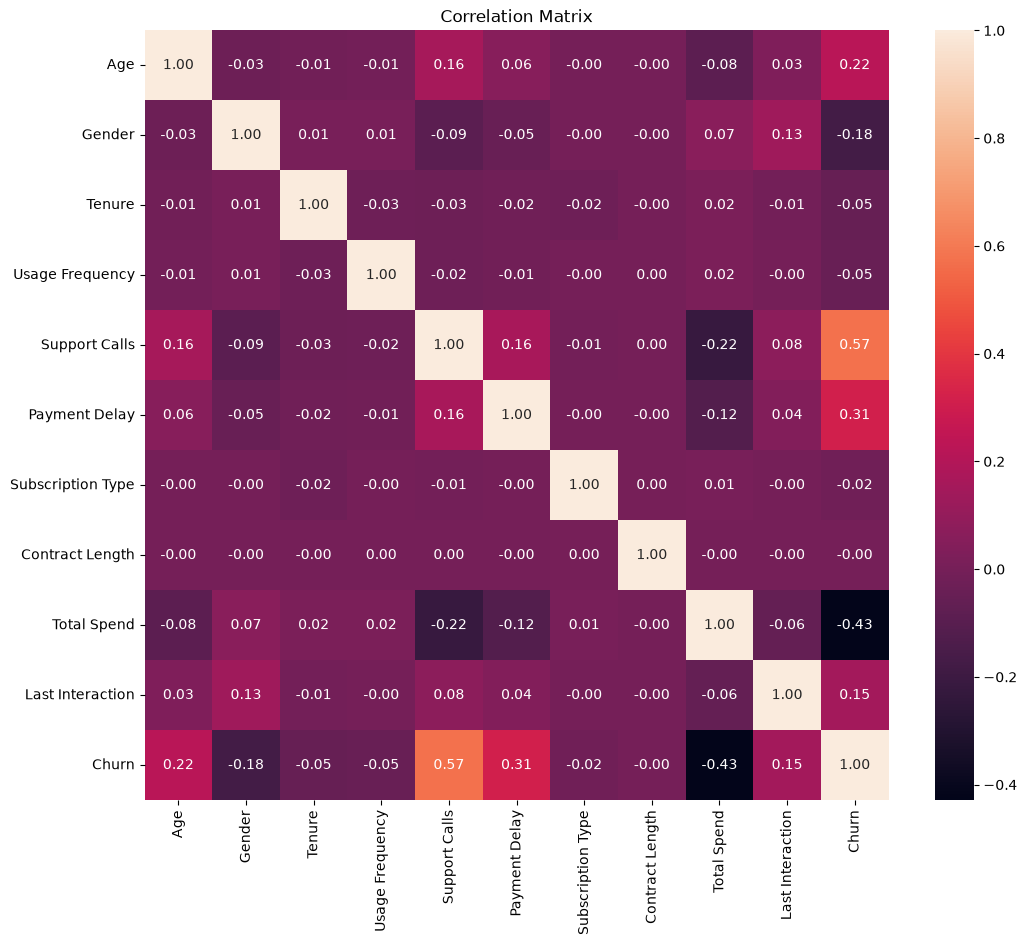

In [63]:
import seaborn as sns

plt.figure(figsize=(12,10))
sns.heatmap(df.corr(), fmt=".2f", annot=True)
plt.title('Correlation Matrix')
plt.show()

In [ ]:
y_prob_test = model.predict_proba(X_test_test)